# La fusión que se nos había escondido

La Vía Láctea se tragó al menos una galaxia entera unos 1.800 millones de años antes de la fusión más antigua que teníamos confirmada. No quedó ni una foto: la pista está en 39 cúmulos de estrellas que orbitan el interior de nuestra galaxia.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Massari et al. (2026). *Evidence of a massive accretion event 1.8 billion years before the Gaia-Sausage-Enceladus merger*. Nature Astronomy.
**DOI:** [10.1038/s41550-026-02931-5](https://doi.org/10.1038/s41550-026-02931-5)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-08-19-fusion-lkh-cumulos-globulares/notebook.ipynb)

**Video:** [Ver en YouTube](https://youtube.com/shorts/YB8he8DhwjU)

## Qué midieron

Un cúmulo globular es una bola de cientos de miles de estrellas que nacieron juntas. Si la Vía Láctea se tragó una galaxia pequeña, los cúmulos de esa galaxia siguen aquí, orbitando: son escombros que no se borran. Por eso sirven de registro fósil de las fusiones.

El problema hasta ahora era la precisión. Para distinguir dos fusiones separadas por menos de 2.000 millones de años hay que datar cúmulos con un error de unas décimas de miles de millones de años — y eso no se lograba. El equipo de Massari usó fotometría del Hubble y comparó cada cúmulo contra modelos de cómo se ve un grupo de estrellas a cada edad — las isócronas — con un método bayesiano (dynesty) para exprimir **edades relativas** mucho más finas.

Con esas edades, los 39 cúmulos se ordenan en el plano edad–metalicidad. La metalicidad, [M/H], mide cuántos elementos pesados tiene una estrella: las galaxias pequeñas se enriquecen despacio, así que cada galaxia progenitora traza su propia curva en ese plano. Tres curvas distintas significan tres orígenes distintos.

Lo que vamos a abrir son tres archivos: los 39 cúmulos con edad, metalicidad y posición; los parámetros ajustados de las dos curvas del paper; y la comparación de precisión contra los dos catálogos de edades anteriores.

> **Aviso de honestidad, y va en serio para todo lo que sigue.** El paper clasifica sus cúmulos con un ajuste bayesiano que no está publicado cúmulo por cúmulo. Lo que tenemos en la tabla pública de CARMA es la asociación **dinámica** de un trabajo de 2019 — anterior al paper y sin la etiqueta LKH. Nuestros grupos son un sustituto razonable, no la clasificación del paper. Cada vez que aparezca un grupo aquí, es el sustituto público.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
RADIO_INTERIOR_KPC = 6.0       # El paper dice que LKH depositó su masa dentro de este radio
ANCLA_GSE_GYR = 10.5           # Época de acreción de GSE tomada de la literatura (ancla del paper)
MH_MIN, MH_MAX = -1.95, -0.35  # Rango de metalicidad donde dibujamos las curvas del modelo
FUENTE = 'Fuente: Massari et al. (2026), Nature Astronomy | Datos: CARMA (INAF) + Tablas suplementarias 1-2'
COLOR_LKH = '#2563EB'          # Azul CaM — el protagonista
COLOR_GSE = '#DC2626'          # Rojo — la fusión que ya conocíamos
COLOR_MW = '#059669'           # Verde — lo que nació aquí mismo
COLOR_REFERENCIA = '#D97706'
COLOR_CONTEXTO = '#BBBBBB'

import os
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
SLUG = '2026-08-19-fusion-lkh-cumulos-globulares'

# Estilo CaM: local -> /tmp -> GitHub raw
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

os.makedirs('figuras', exist_ok=True)
os.makedirs('datos', exist_ok=True)


def cargar(nombre):
    """Carga un CSV local; si no está (p. ej. en Colab), lo baja del repo."""
    ruta = f'datos/{nombre}'
    if not os.path.exists(ruta):
        urllib.request.urlretrieve(f'{BASE}/papers/{SLUG}/datos/{nombre}', ruta)
    return pd.read_csv(ruta)


def es(x, dec=2):
    """Número con coma decimal, como se escribe en español."""
    return f'{x:.{dec}f}'.replace('.', ',')


cg = cargar('cumulos_39.csv')          # 39 cúmulos globulares con edad homogénea
amr = cargar('modelos_amr.csv')        # parámetros ajustados de las curvas LKH y GSE
prec = cargar('precision_edades.csv')  # error medio de edad por catálogo

GRUPOS = ['LKH-cand', 'GSE', 'MW-insitu']
COLORES = {'LKH-cand': COLOR_LKH, 'GSE': COLOR_GSE, 'MW-insitu': COLOR_MW}
ETIQUETAS = {'LKH-cand': 'Candidatos LKH', 'GSE': 'GSE', 'MW-insitu': 'Nacidos aquí'}

print(f'{len(cg)} cúmulos globulares cargados')
print(f'  {(cg.fuente == "SupplTabla1").sum()} con edad nueva de este trabajo')
print(f'  {(cg.fuente == "CARMA-IV").sum()} de la tabla pública CARMA-IV\n')

print('Grupos (etiqueta dinámica pública, NO la clasificación bayesiana del paper):')
for g in GRUPOS:
    s = cg[cg.grupo == g]
    print(f'  {ETIQUETAS[g]:<16} n={len(s):>2}  '
          f'edad {s.edad_gyr.mean():.2f} Gyr  [M/H] {s.mh.mean():+.2f}  '
          f'R_gal mediana {s.r_gc_kpc.median():.2f} kpc')

print(f'\nEdad: media {cg.edad_gyr.mean():.2f} | mediana {cg.edad_gyr.median():.2f} | '
      f'IQR {cg.edad_gyr.quantile(.25):.2f}-{cg.edad_gyr.quantile(.75):.2f} Gyr '
      f'(asimetría {cg.edad_gyr.skew():.2f})')
print(f'Más viejo: {cg.loc[cg.edad_gyr.idxmax(), "nombre"]} '
      f'({cg.edad_gyr.max():.2f} Gyr) | Más joven: {cg.loc[cg.edad_gyr.idxmin(), "nombre"]} '
      f'({cg.edad_gyr.min():.2f} Gyr)')
print('\nParámetros ajustados de las curvas (Suppl. Tabla 2):')
print(amr[['sistema', 'p', 'ti_gyr', 'tf_gyr', 'masa_1e8_msun']].to_string(index=False))

39 cúmulos globulares cargados
  17 con edad nueva de este trabajo
  22 de la tabla pública CARMA-IV

Grupos (etiqueta dinámica pública, NO la clasificación bayesiana del paper):
  Candidatos LKH   n=14  edad 13.34 Gyr  [M/H] -1.27  R_gal mediana 3.94 kpc
  GSE              n=14  edad 12.83 Gyr  [M/H] -1.42  R_gal mediana 9.79 kpc
  Nacidos aquí     n=11  edad 13.51 Gyr  [M/H] -1.01  R_gal mediana 4.76 kpc

Edad: media 13.21 | mediana 13.43 | IQR 13.06-13.71 Gyr (asimetría -0.94)
Más viejo: NGC4372 (14.48 Gyr) | Más joven: NGC2808 (11.09 Gyr)

Parámetros ajustados de las curvas (Suppl. Tabla 2):
sistema     p  ti_gyr  tf_gyr  masa_1e8_msun
    LKH 0.066   14.52   12.19           6.30
    GSE 0.058   14.32   10.43           4.49


Aquí está.

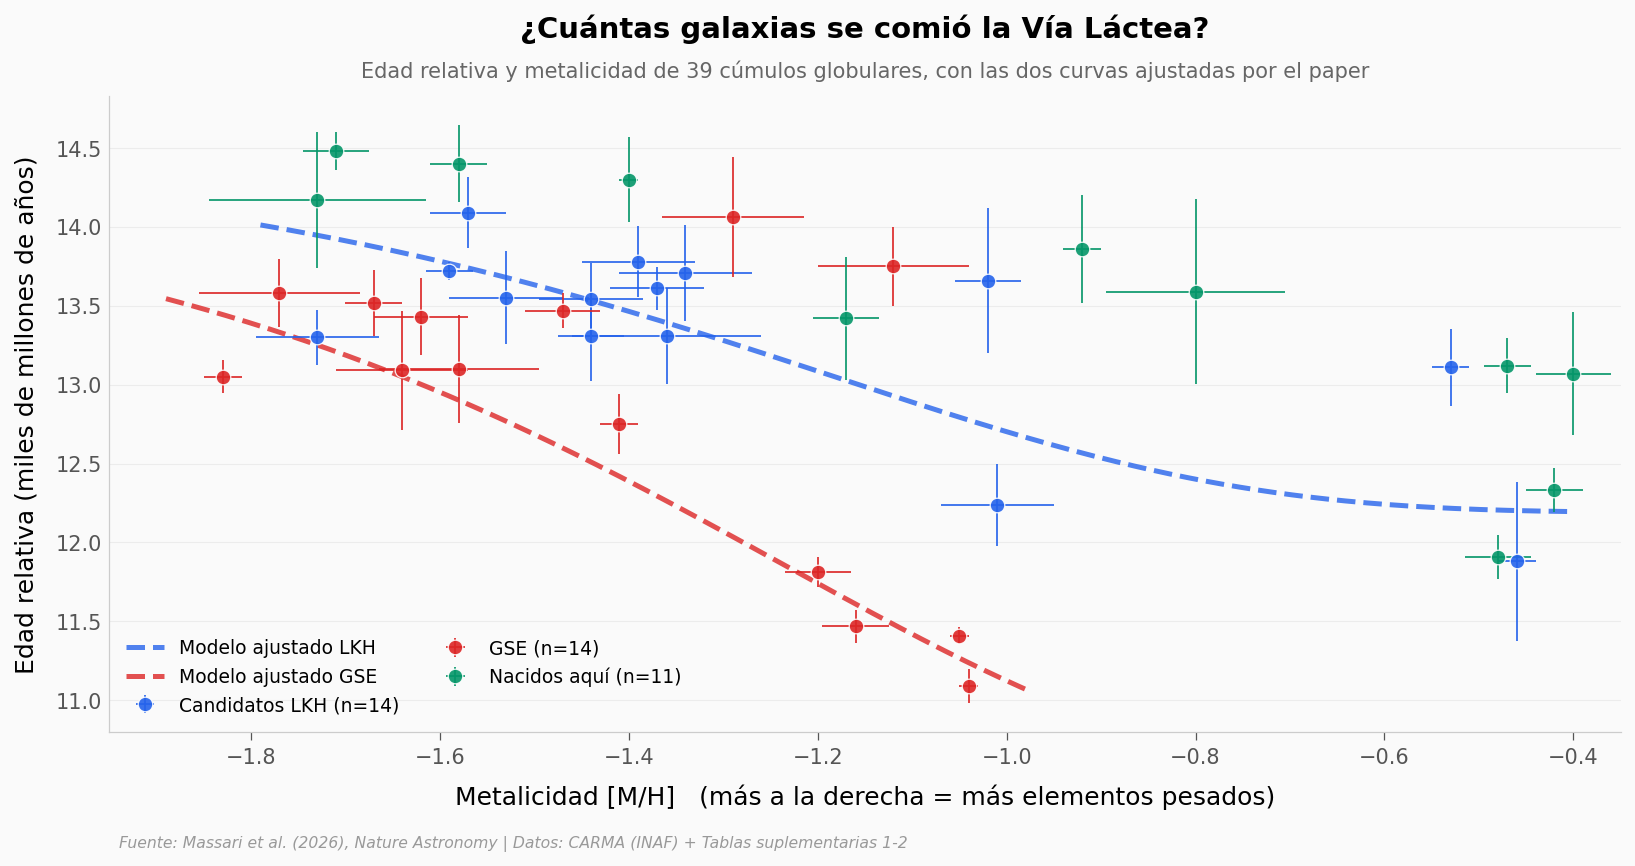

In [2]:
# Ecuación (1) de Methods: edad en función de la metalicidad, para una tasa
# de formación estelar constante. p es el rendimiento químico efectivo.
def curva_amr(mh, p, ti, tf):
    return tf + (ti - tf) * np.exp(-(10 ** mh) / p)


fig, ax = plt.subplots(figsize=(13, 5.5))

for g in GRUPOS:
    s = cg[cg.grupo == g]
    ax.errorbar(s.mh, s.edad_gyr, xerr=s.mh_err, yerr=s.edad_err,
                fmt='o', color=COLORES[g], markersize=7, alpha=0.9,
                markeredgecolor='white', markeredgewidth=0.6,
                elinewidth=0.9, capsize=0, ecolor=COLORES[g],
                label=f'{ETIQUETAS[g]} (n={len(s)})', zorder=5)

# Cada curva se dibuja SOLO sobre el rango de metalicidad que cubren los cúmulos
# de su propio grupo. Extenderla más allá sería extrapolar donde no hay datos.
GRUPO_DE = {'LKH': 'LKH-cand', 'GSE': 'GSE'}
for _, fila in amr.iterrows():
    color = COLOR_LKH if fila.sistema == 'LKH' else COLOR_GSE
    s = cg[cg.grupo == GRUPO_DE[fila.sistema]]
    rejilla = np.linspace(s.mh.min() - 0.06, s.mh.max() + 0.06, 300)
    ax.plot(rejilla, curva_amr(rejilla, fila.p, fila.ti_gyr, fila.tf_gyr),
            color=color, linewidth=2.4, linestyle='--', alpha=0.8, zorder=4,
            label=f'Modelo ajustado {fila.sistema}')

ax.set_title('¿Cuántas galaxias se comió la Vía Láctea?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Edad relativa y metalicidad de 39 cúmulos globulares, con las dos curvas ajustadas por el paper',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Metalicidad [M/H]   (más a la derecha = más elementos pesados)')
ax.set_ylabel('Edad relativa (miles de millones de años)')
ax.set_xlim(MH_MIN, MH_MAX)
ax.legend(fontsize=9, loc='lower left', framealpha=0.9, ncol=2)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/amr_hero.png', dpi=200, bbox_inches='tight')
plt.show()

## Dos caminos que nunca se cruzan

Lo que llama la atención no es un cúmulo suelto: son dos trayectorias paralelas. A cualquier metalicidad, la secuencia de los candidatos a LKH corre sistemáticamente más vieja que la de GSE — y esa diferencia es tiempo puro. Para una misma cantidad de elementos pesados, los cúmulos de LKH nacieron antes.

La lectura física es que las dos galaxias progenitoras se enriquecieron de forma parecida (los rendimientos químicos ajustados son casi iguales: 0,066 y 0,058) pero **dejaron de formar cúmulos en momentos distintos**. La de LKH paró antes. Y la lectura del paper es que una galaxia pequeña deja de formar cúmulos cuando la grande se la traga.

Cuidado con una tentación: la distancia vertical entre las curvas **no** es el titular de 1.800 millones de años. Esa separación depende de la metalicidad: en el rango que cubren estos cúmulos va de 0,61 a 1,76 miles de millones de años. Que el extremo superior se parezca tanto al titular no es una medición, es aritmética de la ecuación — cuanta más metalicidad, más se apaga el término exponencial y más tiende el hueco a la diferencia entre los dos tiempos de acreción. El titular sale de esa diferencia, no de leer el hueco en la curva. Lo desarmamos al final.

Y un aviso importante sobre estas edades: son **relativas**, no absolutas. La escala está anclada al cúmulo más viejo de la muestra, NGC 4372, y depende de los modelos estelares que se usen. Que alguna cifra pase de la edad del Universo no es una contradicción — es que la escala absoluta no es lo que se está midiendo aquí.

## ¿Y dónde quedaron los escombros?

Una fusión no solo deja cúmulos: los deja **en algún sitio**. Una galaxia pequeña que cae temprano y por una órbita de baja energía entrega su material al interior; una que cae después y con más energía lo esparce en el halo exterior.

Así que hay una predicción que podemos poner a prueba con datos públicos. Si los candidatos a LKH vienen de un evento antiguo y central, deberían estar apiñados dentro de los 6 kiloparsecs interiores — unos 20.000 años luz, el corazón de la galaxia. Los de GSE, no.

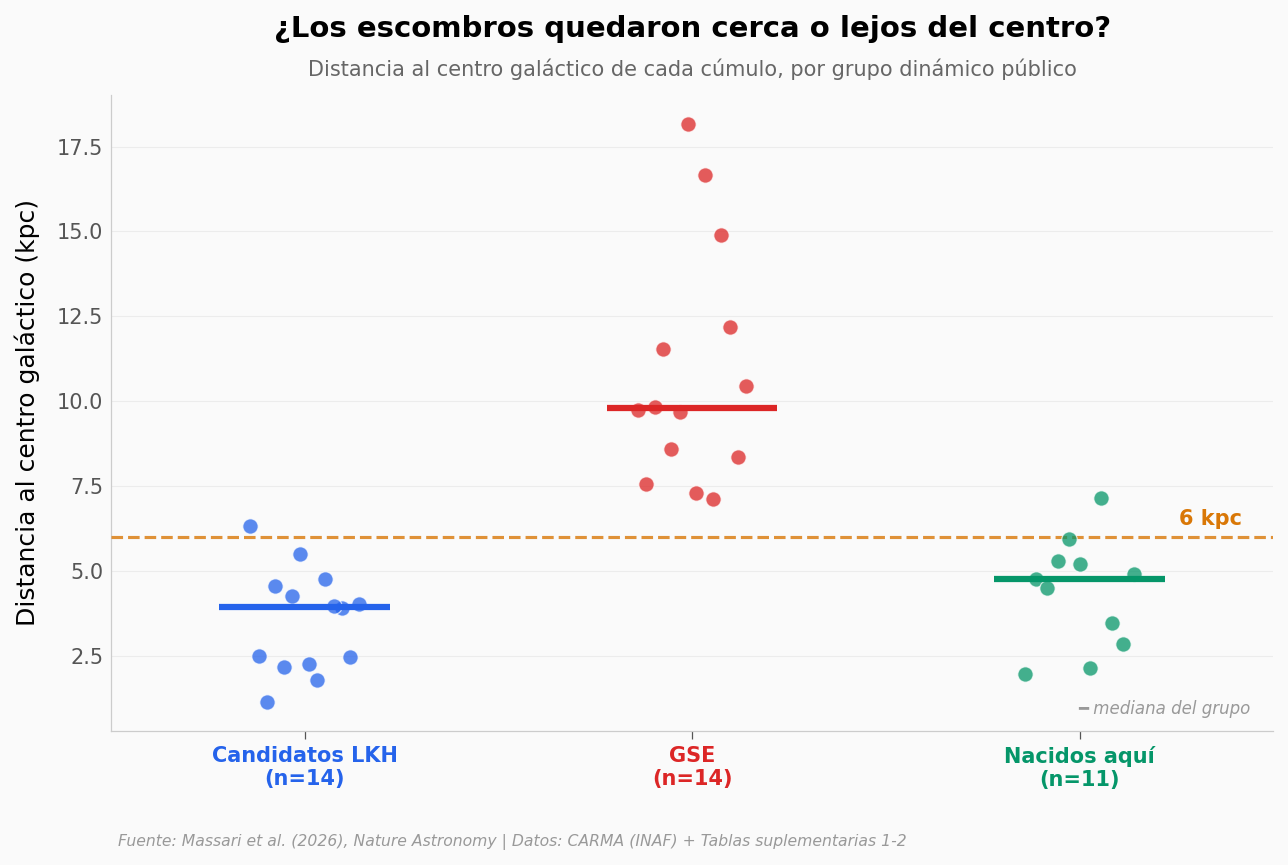

Distancia al centro galáctico — Mann-Whitney U:
Candidatos LKH vs GSE              medianas   3.94 vs   9.79  |  n=14/14  p=7.5e-06  d=2.72
Candidatos LKH vs nacidos aquí     medianas   3.94 vs   4.76  |  n=14/11  p=0.21  d=0.54

Dentro de los 6 kpc interiores:
  Candidatos LKH   13/14 (93%)
  GSE               0/14 (0%)
  Nacidos aquí     10/11 (91%)
  Único candidato LKH fuera: NGC6121 a 6.31 kpc

Edad y metalicidad — Mann-Whitney U:
Edad: candidatos LKH vs GSE        medianas  13.54 vs  13.09  |  n=14/14  p=0.077  d=0.64
Metalicidad: candidatos LKH vs GSE medianas  -1.38 vs  -1.44  |  n=14/14  p=0.3  d=0.44


In [3]:
np.random.seed(42)

fig, ax = plt.subplots(figsize=(10, 5.5))
posiciones = [0, 1, 2]

for i, g in enumerate(GRUPOS):
    s = cg[cg.grupo == g]
    n = len(s)
    x = np.linspace(posiciones[i] - 0.14, posiciones[i] + 0.14, n)
    np.random.shuffle(x)
    ax.scatter(x, s.r_gc_kpc, color=COLORES[g], s=55, alpha=0.75,
               edgecolors='white', linewidths=0.6, zorder=5)
    ax.hlines(s.r_gc_kpc.median(), posiciones[i] - 0.22, posiciones[i] + 0.22,
              color=COLORES[g], linewidth=3, zorder=6)

ax.axhline(RADIO_INTERIOR_KPC, color=COLOR_REFERENCIA, linewidth=1.5,
           linestyle='--', alpha=0.8, zorder=3)
ax.text(2.42, RADIO_INTERIOR_KPC + 0.35, f'{RADIO_INTERIOR_KPC:.0f} kpc',
        fontsize=10, fontweight='bold', color=COLOR_REFERENCIA, ha='right')

ax.set_title('¿Los escombros quedaron cerca o lejos del centro?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Distancia al centro galáctico de cada cúmulo, por grupo dinámico público',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xticks(posiciones)
ax.set_xticklabels([f'{ETIQUETAS[g]}\n(n={len(cg[cg.grupo == g])})' for g in GRUPOS],
                   fontsize=10, fontweight='bold')
for tick, g in zip(ax.get_xticklabels(), GRUPOS):
    tick.set_color(COLORES[g])
ax.set_ylabel('Distancia al centro galáctico (kpc)')
ax.set_xlim(-0.5, 2.5)
ax.text(0.98, 0.02, '━ mediana del grupo', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/radio_galactico.png', dpi=200, bbox_inches='tight')
plt.show()


def comparar(a, b, var, etiqueta):
    """Mann-Whitney (grupos independientes, n<30, sin asumir normalidad)
    + d de Cohen agrupada como tamaño del efecto."""
    A = cg[cg.grupo == a][var]
    B = cg[cg.grupo == b][var]
    _, p = stats.mannwhitneyu(A, B)
    s_pool = np.sqrt(((len(A) - 1) * A.var(ddof=1) + (len(B) - 1) * B.var(ddof=1))
                     / (len(A) + len(B) - 2))
    d = abs(A.mean() - B.mean()) / s_pool
    print(f'{etiqueta:<34} medianas {A.median():>6.2f} vs {B.median():>6.2f}  '
          f'|  n={len(A)}/{len(B)}  p={p:.2g}  d={d:.2f}')


print('Distancia al centro galáctico — Mann-Whitney U:')
comparar('LKH-cand', 'GSE', 'r_gc_kpc', 'Candidatos LKH vs GSE')
comparar('LKH-cand', 'MW-insitu', 'r_gc_kpc', 'Candidatos LKH vs nacidos aquí')

print('\nDentro de los 6 kpc interiores:')
for g in GRUPOS:
    s = cg[cg.grupo == g]
    dentro = (s.r_gc_kpc < RADIO_INTERIOR_KPC).sum()
    print(f'  {ETIQUETAS[g]:<16} {dentro:>2}/{len(s):<2} ({dentro / len(s):.0%})')
fuera = cg[(cg.grupo == 'LKH-cand') & (cg.r_gc_kpc >= RADIO_INTERIOR_KPC)]
print(f'  Único candidato LKH fuera: {fuera.nombre.iloc[0]} a {fuera.r_gc_kpc.iloc[0]:.2f} kpc')

print('\nEdad y metalicidad — Mann-Whitney U:')
comparar('LKH-cand', 'GSE', 'edad_gyr', 'Edad: candidatos LKH vs GSE')
comparar('LKH-cand', 'GSE', 'mh', 'Metalicidad: candidatos LKH vs GSE')

## Lo que la posición sola no resuelve

La separación en distancia es contundente (d = 2,72, p = 0,0000075) y respalda la parte del paper que dice que este material quedó en el interior: 13 de 14 candidatos caen dentro de los 6 kiloparsecs, contra 0 de 14 en GSE.

Pero la posición sola no cierra el caso, y los datos lo dicen sin rodeos. Los candidatos a LKH y los cúmulos nacidos en la propia Vía Láctea están a distancias indistinguibles (p = 0,21, d = 0,54, n = 14 y 11): ambos son poblaciones del interior. Con muestras así de pequeñas, ese efecto medio es tan compatible con una diferencia real que no alcanzamos a ver como con ninguna diferencia. Y con las etiquetas públicas, **la edad por sí sola tampoco separa** a los candidatos de GSE (p = 0,077, por encima del umbral habitual de 0,05, con n = 14 y 14).

Ese es exactamente el punto. La separación del paper no vive en la edad ni en la posición por separado: vive en el plano edad–metalicidad **conjunto**, que es donde la evidencia bayesiana favorece tres secuencias frente a dos. Y eso solo funciona si las edades son lo bastante precisas.

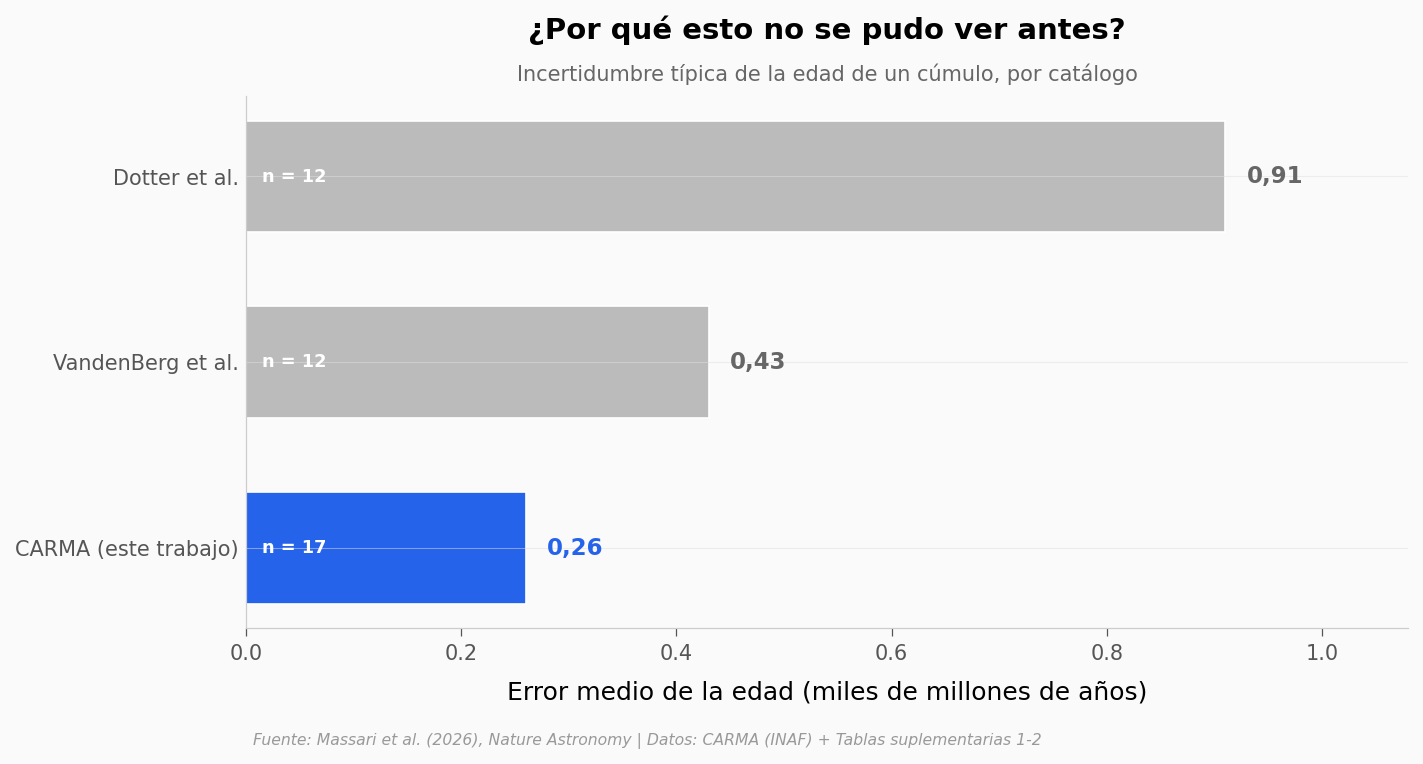

CARMA: 0.26 Gyr sobre 17 cúmulos nuevos
  Dotter et al.: 0.91 Gyr (3.5 veces mayor, n=12 cúmulos en común)
  VandenBerg et al.: 0.43 Gyr (1.7 veces mayor, n=12 cúmulos en común)

Error medio que reproducimos con los 17 cúmulos nuevos: 0,251 mil millones de años (el paper da 0,26)


In [4]:
fig, ax = plt.subplots(figsize=(10, 4.6))

orden = prec.sort_values('error_medio_gyr')
colores_barras = [COLOR_LKH if 'CARMA' in m else COLOR_CONTEXTO for m in orden.metodo]
barras = ax.barh(range(len(orden)), orden.error_medio_gyr,
                 color=colores_barras, height=0.6, edgecolor='white', linewidth=0.8)

for i, (_, fila) in enumerate(orden.iterrows()):
    ax.text(fila.error_medio_gyr + 0.02, i, es(fila.error_medio_gyr),
            va='center', fontsize=11, fontweight='bold',
            color=COLOR_LKH if 'CARMA' in fila.metodo else '#666666')
    ax.text(0.015, i, f'n = {fila.n_cumulos_comun}', va='center', fontsize=8.5,
            color='white', fontweight='bold')

ax.set_yticks(range(len(orden)))
ax.set_yticklabels(orden.metodo, fontsize=10)
ax.set_xlabel('Error medio de la edad (miles de millones de años)')
ax.set_xlim(0, 1.08)
ax.set_title('¿Por qué esto no se pudo ver antes?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Incertidumbre típica de la edad de un cúmulo, por catálogo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.06, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/precision_edades.png', dpi=200, bbox_inches='tight')
plt.show()

carma = prec[prec.metodo.str.contains('CARMA')].iloc[0]
otros = prec[~prec.metodo.str.contains('CARMA')]
print(f'CARMA: {carma.error_medio_gyr:.2f} Gyr sobre {carma.n_cumulos_comun} cúmulos nuevos')
for _, fila in otros.iterrows():
    print(f'  {fila.metodo}: {fila.error_medio_gyr:.2f} Gyr '
          f'({fila.error_medio_gyr / carma.error_medio_gyr:.1f} veces mayor, '
          f'n={fila.n_cumulos_comun} cúmulos en común)')
print(f'\nError medio que reproducimos con los 17 cúmulos nuevos: '
      f'{es(cg[cg.fuente == "SupplTabla1"].edad_err.mean(), 3)} mil millones de años '
      f'(el paper da 0,26)')

## De dónde sale el 1,8

Ahora sí, el número del titular. No se mide: se ajusta.

Cada curva del modelo tiene un parámetro `t_f`, el momento en que esa galaxia dejó de formar cúmulos — que es la firma de cuándo la Vía Láctea se la tragó. El ajuste da 12,19 para LKH y 10,43 para GSE. La resta es 1,76 miles de millones de años, y de ahí sale el «1,8» del título del paper.

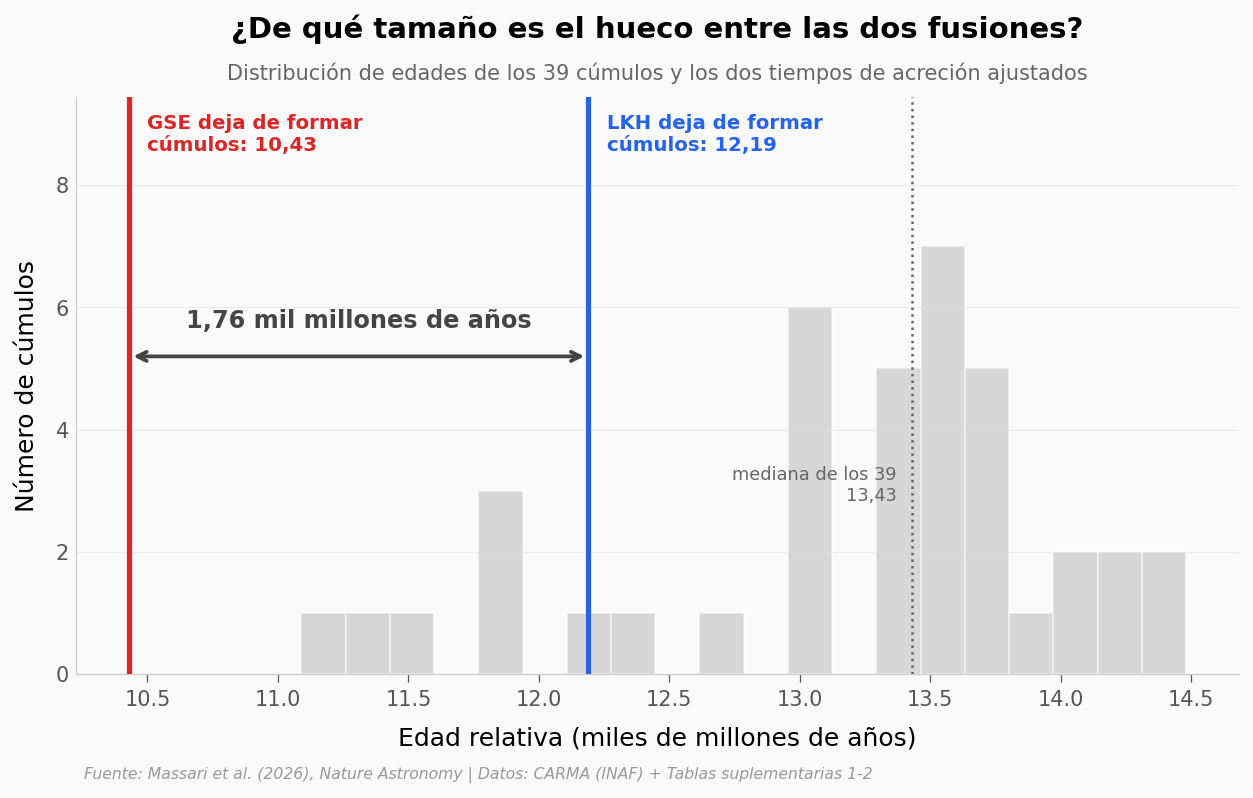

Diferencia de tiempos de acreción ajustados: 1.76 Gyr (el paper redondea a ~1,8)
Incertidumbres de t_f: LKH +0.49/-0.59, GSE +0.65/-0.67 Gyr
Anclando GSE en 10.5 Gyr (literatura), LKH cayó hace 12.26 Gyr — el paper dice ~12,3

Propagando los errores en cuadratura: 1.76 +0.81/-0.89 Gyr
  es decir, compatible con un hueco entre 0.87 y 2.57 Gyr

Separación VERTICAL entre las curvas (esto NO es el 1,8):
  a [M/H] = -1.83: 0.61 Gyr
  a [M/H] = -1.40: 1.08 Gyr
  a [M/H] = -1.00: 1.58 Gyr
  a [M/H] = -0.40: 1.76 Gyr
  (rango de metalicidad observado: -1.83 a -0.40)

Masas ajustadas de los progenitores:
  LKH: 6.30e8 masas solares (+8.95/-3.6)
  GSE: 4.49e8 masas solares (+5.69/-2.36)
  Los intervalos se solapan: el paper las llama consistentes entre sí, no una mayor que otra.


In [5]:
lkh = amr[amr.sistema == 'LKH'].iloc[0]
gse = amr[amr.sistema == 'GSE'].iloc[0]
delta_tf = lkh.tf_gyr - gse.tf_gyr

fig, ax = plt.subplots(figsize=(10, 5))
n, bins, _ = ax.hist(cg.edad_gyr, bins=20, color=COLOR_CONTEXTO, alpha=0.55,
                     edgecolor='white', linewidth=0.8)
y_max = n.max() * 1.35
ax.set_ylim(0, y_max)

ax.axvline(lkh.tf_gyr, color=COLOR_LKH, linewidth=2.5, zorder=5)
ax.axvline(gse.tf_gyr, color=COLOR_GSE, linewidth=2.5, zorder=5)
ax.text(lkh.tf_gyr + 0.07, y_max * 0.97, f'LKH deja de formar\ncúmulos: {es(lkh.tf_gyr)}',
        fontsize=9.5, color=COLOR_LKH, fontweight='bold', va='top')
ax.text(gse.tf_gyr + 0.07, y_max * 0.97, f'GSE deja de formar\ncúmulos: {es(gse.tf_gyr)}',
        fontsize=9.5, color=COLOR_GSE, fontweight='bold', va='top')

ax.annotate('', xy=(lkh.tf_gyr, y_max * 0.55), xytext=(gse.tf_gyr, y_max * 0.55),
            arrowprops=dict(arrowstyle='<->', color='#444444', lw=1.8))
ax.text((lkh.tf_gyr + gse.tf_gyr) / 2, y_max * 0.60,
        f'{es(delta_tf)} mil millones de años',
        fontsize=11.5, fontweight='bold', color='#444444', ha='center')

ax.axvline(cg.edad_gyr.median(), color='#666666', linewidth=1.2, linestyle=':', zorder=4)
ax.text(cg.edad_gyr.median() - 0.06, y_max * 0.30,
        f'mediana de los 39\n{es(cg.edad_gyr.median())}', fontsize=8.5,
        color='#666666', ha='right')

ax.set_title('¿De qué tamaño es el hueco entre las dos fusiones?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Distribución de edades de los 39 cúmulos y los dos tiempos de acreción ajustados',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Edad relativa (miles de millones de años)')
ax.set_ylabel('Número de cúmulos')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hueco_fusiones.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Diferencia de tiempos de acreción ajustados: {delta_tf:.2f} Gyr '
      f'(el paper redondea a ~1,8)')
print(f'Incertidumbres de t_f: LKH +{lkh.tf_err_sup}/-{lkh.tf_err_inf}, '
      f'GSE +{gse.tf_err_sup}/-{gse.tf_err_inf} Gyr')
print(f'Anclando GSE en {ANCLA_GSE_GYR} Gyr (literatura), LKH cayó hace '
      f'{ANCLA_GSE_GYR + delta_tf:.2f} Gyr — el paper dice ~12,3\n')

# Propagación en cuadratura de los errores asimétricos de los dos t_f
err_sup = np.hypot(lkh.tf_err_sup, gse.tf_err_sup)
err_inf = np.hypot(lkh.tf_err_inf, gse.tf_err_inf)
print(f'Propagando los errores en cuadratura: {delta_tf:.2f} +{err_sup:.2f}/-{err_inf:.2f} Gyr')
print(f'  es decir, compatible con un hueco entre {delta_tf - err_inf:.2f} y {delta_tf + err_sup:.2f} Gyr\n')

print('Separación VERTICAL entre las curvas (esto NO es el 1,8):')
for x in [cg.mh.min(), -1.4, -1.0, cg.mh.max()]:
    sep = curva_amr(x, lkh.p, lkh.ti_gyr, lkh.tf_gyr) - curva_amr(x, gse.p, gse.ti_gyr, gse.tf_gyr)
    print(f'  a [M/H] = {x:>5.2f}: {sep:.2f} Gyr')
print(f'  (rango de metalicidad observado: {cg.mh.min():.2f} a {cg.mh.max():.2f})')

print(f'\nMasas ajustadas de los progenitores:')
print(f'  LKH: {lkh.masa_1e8_msun:.2f}e8 masas solares (+{lkh.masa_err_sup}/-{lkh.masa_err_inf})')
print(f'  GSE: {gse.masa_1e8_msun:.2f}e8 masas solares (+{gse.masa_err_sup}/-{gse.masa_err_inf})')
print('  Los intervalos se solapan: el paper las llama consistentes entre sí, no una mayor que otra.')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Los 39 cúmulos trazan más de una secuencia en el plano edad–metalicidad | ✅ | Las dos curvas ajustadas del paper (Tabla suplementaria 2) reproducen la figura y no se cruzan en todo el rango observado. La evidencia bayesiana del paper favorece tres secuencias sobre dos (Δ log Z = 5,3) — ese ajuste es del paper, no lo recalculamos aquí |
| Las dos fusiones están separadas por unos 1.800 millones de años | ⚠️ | 12,19 − 10,43 = 1,76 mil millones de años, reproducido exacto. Pero es una **diferencia entre parámetros ajustados**, y sus errores son grandes y asimétricos (+0,49/−0,59 para LKH, +0,65/−0,67 para GSE). Propagados en cuadratura dan 1,76 +0,81/−0,89: el dato es compatible con un hueco de 0,87 y con uno de 2,57 mil millones de años. El paper lo enmarca como estimación |
| El material de LKH quedó en los 6 kiloparsecs interiores | ✅ | 13/14 candidatos dentro de 6 kpc contra 0/14 en GSE. Mann-Whitney p = 0,0000075, d = 2,72 (efecto grande). Es el resultado más sólido del notebook. Único candidato fuera: NGC 6121 (M4) a 6,31 kpc. Ojo: los nacidos aquí también están dentro (10/11), así que el radio separa de GSE pero no identifica a LKH por sí solo |
| Los cúmulos de LKH son más viejos que los de GSE | ❌ | Con las etiquetas públicas la edad sola **no** separa: p = 0,077, d = 0,64, n = 14/14. La diferencia de medias es 0,52 mil millones de años. La separación del paper vive en el plano conjunto edad–metalicidad, no en la edad aislada |
| El progenitor tenía una masa parecida a la de GSE | ⚠️ | Ajustes: LKH 6,30 × 10⁸ y GSE 4,49 × 10⁸ masas solares, con errores enormes y asimétricos (+8,95/−3,60 y +5,69/−2,36). Los intervalos se solapan: consistentes entre sí, sin poder decir cuál fue mayor |
| Las edades nuevas son más precisas que las anteriores | ⚠️ | 0,26 mil millones de años contra 0,91 (Dotter) y 0,43 (VandenBerg): el salto es de 3,5 veces contra un catálogo y de 1,7 contra el otro, así que «unas tres veces» solo vale para la comparación con Dotter. Reproducimos 0,251 mil millones de años promediando los errores de los 17 cúmulos nuevos — 3,5% de diferencia con el valor del paper |
| Fue **una** galaxia la que cayó | ⚠️ | El abstract dice "al menos una fusión". El propio paper deja abierto que la tercera secuencia corresponda a más de un evento |

> **Limitaciones, y son varias:**
>
> - **Nuestros grupos no son los del paper.** La columna de asociación dinámica que usamos viene de la tabla pública de CARMA (30/10/2025), anterior al paper, y refleja la clasificación de Massari, Koppelman & Helmi 2019. No contiene la etiqueta LKH. Nuestro grupo de candidatos tiene 14 cúmulos; el paper cuenta 12 miembros de LKH según su ajuste bayesiano — **son dos conjuntos distintos**, no los mismos objetos.
> - **La lista de los 39 es una reconstrucción nuestra.** El paper no la publica explícita. Combinamos las 17 filas nuevas de su Tabla suplementaria 1 con 22 de CARMA-IV y da exactamente 39, pero la coincidencia del total no garantiza que sean los mismos 39.
> - **Grupos pequeños:** n = 14, 14 y 11. Muy por debajo de 30, así que usamos Mann-Whitney y reportamos el tamaño del efecto en cada comparación.
> - **Las edades son relativas, no absolutas.** La escala está anclada al cúmulo más viejo (NGC 4372, 14,48 mil millones de años) y depende de los modelos estelares BaSTI. No sirven para fechar el Universo.
> - **La distancia al centro galáctico la calculamos nosotros** a partir del módulo de distancia y las coordenadas, con el Sol a 8,122 kpc. Ese cálculo se hizo fuera de este notebook y llega ya resuelto en el CSV, así que estas celdas no lo reproducen. La columna de distancia del catálogo es heliocéntrica y no sirve para hablar de los 6 kpc interiores.
> - **Diseño observacional.** Nadie hizo el experimento: se miran objetos que ya estaban ahí. Cuando el paper dice que la fusión depositó masa en el interior, eso es una inferencia del paper a partir del patrón, no una medición directa.

## Ahora tú

**1. ¿Qué pasa si el ancla de GSE está mal?** Todo el «LKH cayó hace 12,3 mil millones de años» descansa en fijar GSE en 10,5, un valor tomado de la literatura. Cambia `ANCLA_GSE_GYR` en la celda de configuración a 10,0 o a 11,0 y vuelve a correr. La diferencia de 1,76 no se mueve — pero la fecha absoluta sí.

**2. ¿Cuánto pesa cada cúmulo en la separación?** Quita el candidato que más ayuda al resultado — el más cercano al centro — y mira si aguanta: `cg_sin = cg.drop(cg[cg.grupo == 'LKH-cand'].r_gc_kpc.idxmin())` y repite el Mann-Whitney sobre esa tabla. Ese es el test: si el efecto sobrevive a perder su mejor punto, es robusto. Ojo con hacerlo al revés — quitar el más lejano (`idxmax()`, que es NGC 6121, el único fuera de los 6 kpc) **sube** el efecto en vez de exigirlo.

**3. ¿Dónde se separan más las dos curvas?** La separación vertical crece con la metalicidad. Prueba a graficar `curva_amr` de LKH menos la de GSE sobre todo el rango y busca dónde el hueco supera los mil millones de años. Esa es la zona del plano donde un solo cúmulo bien datado distingue a qué galaxia perteneció.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Aguanta la separación en distancia si le quitamos el mejor punto?
# Sacamos el candidato a LKH más cercano al centro (el que más ayuda al resultado)
# y repetimos la prueba con los 13 que quedan.

lkh_cand = cg[cg.grupo == 'LKH-cand']
mas_central = lkh_cand.r_gc_kpc.idxmin()
print(f'Quitamos {cg.loc[mas_central, "nombre"]} '
      f'(el más central, a {cg.loc[mas_central, "r_gc_kpc"]:.2f} kpc)\n')

recortado = lkh_cand.drop(mas_central).r_gc_kpc
gse_r = cg[cg.grupo == 'GSE'].r_gc_kpc

_, p_orig = stats.mannwhitneyu(lkh_cand.r_gc_kpc, gse_r)
_, p_rec = stats.mannwhitneyu(recortado, gse_r)

s_pool = np.sqrt(((len(recortado) - 1) * recortado.var(ddof=1)
                  + (len(gse_r) - 1) * gse_r.var(ddof=1))
                 / (len(recortado) + len(gse_r) - 2))
d_rec = abs(recortado.mean() - gse_r.mean()) / s_pool

print(f'Con los 14 candidatos: p = {p_orig:.2g}')
print(f'Con 13 candidatos:     p = {p_rec:.2g}  (d = {d_rec:.2f})')
print(f'Mediana sin ese cúmulo: {recortado.median():.2f} kpc '
      f'(antes {lkh_cand.r_gc_kpc.median():.2f})')
print('\nEl efecto no depende de un solo objeto.')

# Tu turno: prueba quitando el más lejano en vez del más cercano,
# o repite el ejercicio sobre la edad en lugar de la distancia.

Quitamos NGC6401 (el más central, a 1.15 kpc)

Con los 14 candidatos: p = 7.5e-06
Con 13 candidatos:     p = 1.1e-05  (d = 2.64)
Mediana sin ese cúmulo: 3.98 kpc (antes 3.94)

El efecto no depende de un solo objeto.


---

## Cómo reproducir esto

Todo lo que hay arriba sale de tres CSV de menos de 5 KB y de la ecuación (1) de los Methods del paper. Los datos y este notebook viven en [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab/tree/main/papers/2026-08-19-fusion-lkh-cumulos-globulares), y el botón de Colab de arriba lo abre sin instalar nada.

## Fuentes

**Paper**: [Evidence of a massive accretion event 1.8 billion years before the Gaia-Sausage-Enceladus merger](https://doi.org/10.1038/s41550-026-02931-5)  
*Nature Astronomy, 2026-08-17*

**Supplementary Material**: [Supplementary Information: Supplementary Tables 1-2 (ajuste de isócronas y parámetros de LKH/GSE)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41550-026-02931-5/MediaObjects/41550_2026_2931_MOESM1_ESM.pdf)  
*mismo DOI que el paper*

**Dataset canónico**: [CARMA: tabla de edades y asociaciones de cúmulos globulares (Gaia eDR3 / CARMA-IV, 30/10/2025)](https://www.oas.inaf.it/en/research/m2-en/carma-en)  
*INAF OAS Bologna, 2025-10-30*

**Referencias citadas**: [STScI](https://archive.stsci.edu/prepds/hugs) · [Astronomy & Astrophysics](https://doi.org/10.1051/0004-6361/201936135)

*16 afirmaciones del notebook verificadas contra estas fuentes*